In [1]:
import os
import pandas as pd
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt

### Functions

In [2]:
def phi_coefficient(df, str_col_target, str_col):
    # both 1
    int_n_11 = df.apply(
        lambda x: 1 if (x[str_col_target] == 1) and (x[str_col] == 1) else 0,
        axis=1,
    ).sum()
    # both 0
    int_n_00 = df.apply(
        lambda x: 1 if (x[str_col_target] == 0) and (x[str_col] == 0) else 0,
        axis=1,
    ).sum()
    # target 0 col 1
    int_n_01 = df.apply(
        lambda x: 1 if (x[str_col_target] == 0) and (x[str_col] == 1) else 0,
        axis=1,
    ).sum()
    # target 1 col 0
    int_n_10 = df.apply(
        lambda x: 1 if (x[str_col_target] == 1) and (x[str_col] == 0) else 0,
        axis=1,
    ).sum()
    # get numerator
    flt_numerator = (int_n_11 * int_n_00) - (int_n_10 * int_n_01)

    # counts of 1s in first vector
    int_n_1_target = df[str_col_target].sum()
    # counts of 0s in first vector
    int_n_0_target = df.shape[0] - df[str_col_target].sum()
    # counts of 1s in second vector
    int_n_1_second = df[str_col].sum()
    # counts of 0s in second vector
    int_n_0_second = df.shape[0] - df[str_col].sum()
    # get denominator
    flt_denominator = math.sqrt(int_n_1_target*int_n_0_target*int_n_1_second*int_n_0_second)

    # get phi
    flt_phi = flt_numerator / flt_denominator
    
    # return
    return flt_phi

### Constants

In [3]:
str_dirname_output = './output'

# we want early indicators at 2, 3, 6, and 12 months
list_int_months = [
    2,
    3,
    6,
    12,
]
# make into days
list_int_days = [int_month*30 for int_month in list_int_months]
print(f'Days on Books Targets: {list_int_days}')

# target
str_target = 'Early_Pay_Delinquency_60_720_Flag'

Days on Books Targets: [60, 90, 180, 360]


### Make output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import targets

In [5]:
str_filename = 'df_targets.gzip'
str_uri = f's3://20240327-genxii-v2/02_target_creation/01_classification/{str_filename}'
df = pd.read_parquet(str_uri)
df

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:283: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


,bigAccountId,Early_Pay_Delinquency_15_60_Flag,Early_Pay_Delinquency_30_90_Flag,Early_Pay_Delinquency_30_180_Flag,Early_Pay_Delinquency_30_360_Flag,Early_Pay_Delinquency_60_720_Flag,bitDefault,defaultDate
0,6,0,0,0,0,0,1.0,2008-12-03 15:01:09.283
1,25,1,0,0,1,1,1.0,1993-01-27 00:00:00.000
2,73,0,0,0,0,1,1.0,1993-01-27 00:00:00.000
3,82,1,1,1,1,1,1.0,1993-01-27 00:00:00.000
4,122,0,0,0,1,1,1.0,1993-01-27 00:00:00.000
...,...,...,...,...,...,...,...,...
343069,8619039,0,0,0,0,0,0.0,NaT
343070,8619083,0,0,0,0,0,0.0,NaT
343071,8619360,0,0,0,0,0,0.0,NaT
343072,8619910,0,0,0,0,0,0.0,NaT


### Get those that meet our criteria

In [6]:
list_cols = [col for col in df.columns if 'Early' in col]
df_tmp = pd.DataFrame({'col': list_cols})

# get days past due
df_tmp['days_past_due'] = df_tmp['col'].apply(
    lambda x: int(x.split('_')[3]),
)

# get days
df_tmp['days_on_books'] = df_tmp['col'].apply(
    lambda x: int(x.split('_')[4]),
)

# subset
df_tmp = df_tmp[df_tmp['days_on_books'].isin(list_int_days)].copy()

# subset dpd
df_tmp = df_tmp[df_tmp['days_past_due'] > 1].copy()

# sort
df_tmp.sort_values(by=['days_on_books','days_past_due'], ascending=[True,True], inplace=True)

# show
df_tmp

,col,days_past_due,days_on_books
0,Early_Pay_Delinquency_15_60_Flag,15,60
1,Early_Pay_Delinquency_30_90_Flag,30,90
2,Early_Pay_Delinquency_30_180_Flag,30,180
3,Early_Pay_Delinquency_30_360_Flag,30,360


### Subset targets

In [7]:
list_cols = list(df_tmp['col'])
list_cols = ['bigAccountId', str_target] + list_cols
# subset
df = df[list_cols].copy()
# rename
dict_rename = {
    str_target: 'target',
}
df.rename(columns=dict_rename, inplace=True)
# show
df

,bigAccountId,target,Early_Pay_Delinquency_15_60_Flag,Early_Pay_Delinquency_30_90_Flag,Early_Pay_Delinquency_30_180_Flag,Early_Pay_Delinquency_30_360_Flag
0,6,0,0,0,0,0
1,25,1,1,0,0,1
2,73,1,0,0,0,0
3,82,1,1,1,1,1
4,122,1,0,0,0,1
...,...,...,...,...,...,...
343069,8619039,0,0,0,0,0
343070,8619083,0,0,0,0,0
343071,8619360,0,0,0,0,0
343072,8619910,0,0,0,0,0


### Import more recent PD data

In [8]:
list_cols = [
    'bigAccountId',
]
str_filename = 'df_raw.gzip'
str_uri = f's3://20240327-genxii-v2/04_pd/01_data_prep/01_data_collection/{str_filename}'
df_tmp = pd.read_parquet(str_uri, columns=list_cols)
df_tmp

,bigAccountId
0,5514485
1,5515245
2,5517730
3,5514970
4,5515580
...,...
43823,6513617
43824,6483306
43825,6483306
43826,6502220


### Join

In [9]:
df = pd.merge(
    left=df_tmp,
    right=df,
    on='bigAccountId',
    how='left',
)
# show
df

,bigAccountId,target,Early_Pay_Delinquency_15_60_Flag,Early_Pay_Delinquency_30_90_Flag,Early_Pay_Delinquency_30_180_Flag,Early_Pay_Delinquency_30_360_Flag
0,5514485,0,0,0,0,0
1,5515245,0,0,0,0,0
2,5517730,0,0,0,0,0
3,5514970,0,0,0,0,0
4,5515580,0,0,0,0,0
...,...,...,...,...,...,...
43823,6513617,0,0,0,0,0
43824,6483306,0,0,0,0,0
43825,6483306,0,0,0,0,0
43826,6502220,1,0,0,1,1


### Compare all flag columns to the target

In [10]:
list_cols = [col for col in df.columns if col not in ['bigAccountId','target']]
list_dict_row = []
for col in tqdm(list_cols):
    # get coefficient
    flt_phi = phi_coefficient(
        df=df,
        str_col_target='target',
        str_col=col,
    )
    # dict row
    dict_row = {
        'col': col,
        'phi': flt_phi,
    }
    list_dict_row.append(dict_row)
df = pd.DataFrame(list_dict_row)
df

100%|██████████| 4/4 [00:04<00:00,  1.06s/it]


,col,phi
0,Early_Pay_Delinquency_15_60_Flag,0.272447
1,Early_Pay_Delinquency_30_90_Flag,0.309964
2,Early_Pay_Delinquency_30_180_Flag,0.470219
3,Early_Pay_Delinquency_30_360_Flag,0.620669


### Get the days on books

In [11]:
df['days_on_books'] = df['col'].apply(
    lambda x: int(x.split('_')[4]),
)
df

,col,phi,days_on_books
0,Early_Pay_Delinquency_15_60_Flag,0.272447,60
1,Early_Pay_Delinquency_30_90_Flag,0.309964,90
2,Early_Pay_Delinquency_30_180_Flag,0.470219,180
3,Early_Pay_Delinquency_30_360_Flag,0.620669,360


### Get the row with the max phi at each days on books

In [12]:
ser_idx_max = df.groupby(by='days_on_books')['phi'].idxmax()
df = df.loc[ser_idx_max].copy()
df

,col,phi,days_on_books
0,Early_Pay_Delinquency_15_60_Flag,0.272447,60
1,Early_Pay_Delinquency_30_90_Flag,0.309964,90
2,Early_Pay_Delinquency_30_180_Flag,0.470219,180
3,Early_Pay_Delinquency_30_360_Flag,0.620669,360


### Save

In [13]:
str_filename = 'df_early_indicator_targets.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

### Plot it

/tmp/ipykernel_17769/1064501227.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45)


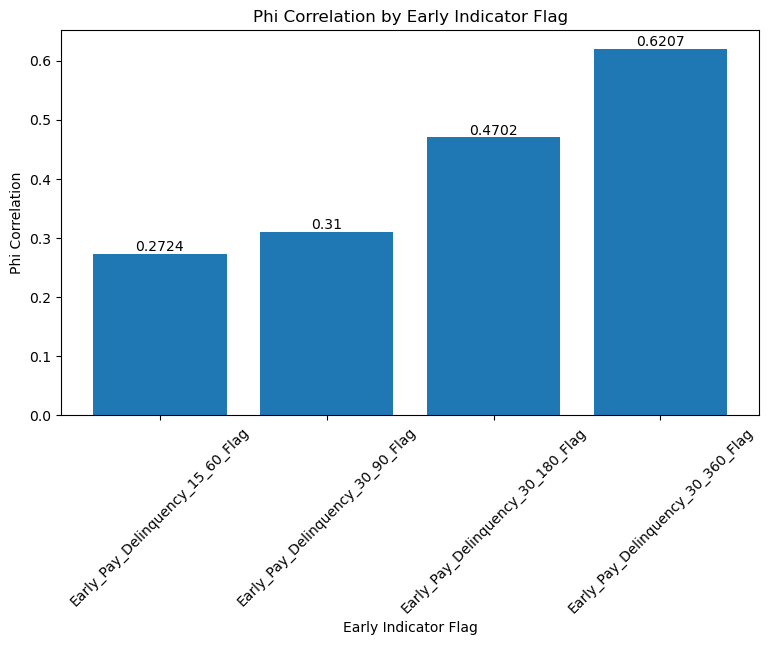

In [14]:
x = df['col']
y = df['phi']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Phi Correlation by Early Indicator Flag')
ax.set_xlabel('Early Indicator Flag')
ax.set_ylabel('Phi Correlation')
bars = ax.bar(x, y)

# add value labels
for bar, value in zip(bars, y):
    ax.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height(), # vertical alignment
        round(value, 4),  # 4 decimal places
        ha='center', va='bottom', rotation=0, # horizontal alignment
    )  

# rotate x ticks
ax.set_xticklabels(x, rotation=45)
# show
plt.show()